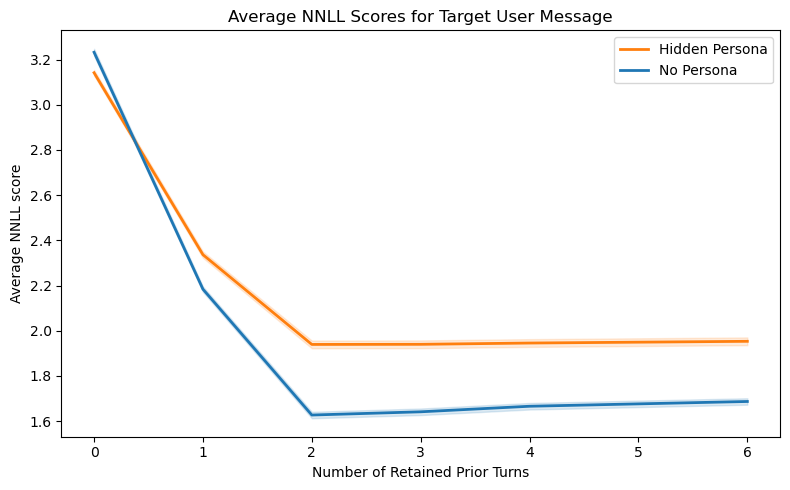

,condition,n_turns_context,mean_nll,std_nll,n,se_nll
0,hidden_persona,0,3.141895,0.439325,1250,0.012426
1,hidden_persona,1,2.336663,0.491393,1250,0.013899
2,hidden_persona,2,1.939495,0.600478,1250,0.016984
3,hidden_persona,3,1.940031,0.609229,1250,0.017232
4,hidden_persona,4,1.945695,0.608455,1250,0.017210
5,hidden_persona,6,1.953305,0.607663,1250,0.017187
6,no_persona,0,3.232534,0.540769,1250,0.015295
7,no_persona,1,2.183894,0.428488,1250,0.012119
8,no_persona,2,1.627071,0.503980,1250,0.014255
9,no_persona,3,1.641357,0.514129,1250,0.014542


In [2]:
import json
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) File paths
# =========================
CONV_PATH = "/users/eleves-a/2023/allegra-maria-pia.boustany/llm-cross-eval/src/data/conversations/llm_vs_llm_conversations_20260127_212002.jsonl"
SCORES_PATH = "/users/eleves-a/2023/allegra-maria-pia.boustany/llm-cross-eval/src/data/scores/output_scores_20260128_071446.jsonl"

# =========================
# 2) Build mapping:
#    (conversation_id, target_user_msg_idx) -> user_turn_number_after_seed
# =========================
idx_to_userturn = {}

with open(CONV_PATH, "r") as f:
    for line in f:
        if not line.strip():
            continue
        conv = json.loads(line)
        cid = conv["conversation_id"]
        msgs = conv["messages"]

        # Indices of all user messages
        user_idxs = [i for i, m in enumerate(msgs) if m["role"] == "user"]

        # Skip the seed user message
        user_idxs_after_seed = user_idxs[1:]

        # Map each scored user message to its turn number after seed
        for turn_num, msg_idx in enumerate(user_idxs_after_seed, start=1):
            idx_to_userturn[(cid, msg_idx)] = turn_num

# =========================
# 3) Load scores into DataFrame
# =========================
rows = []
with open(SCORES_PATH, "r") as f:
    for line in f:
        if not line.strip():
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

# Map each scored row to its user turn index
df["user_turn"] = df.apply(
    lambda r: idx_to_userturn.get((r["conversation_id"], r["target_user_msg_idx"]), np.nan),
    axis=1
)

df = df.dropna(subset=["user_turn"]).copy()
df["user_turn"] = df["user_turn"].astype(int)

# Compute NNLL = - avg logprob
df["nll_per_token"] = -df["avg_logprob"]

# =========================
# 4) Aggregate over ALL target user turns
#    for each condition and context depth
# =========================
plot_df = (
    df.groupby(["condition", "n_turns_context"], as_index=False)
      .agg(
          mean_nll=("nll_per_token", "mean"),
          std_nll=("nll_per_token", "std"),
          n=("nll_per_token", "size")
      )
)

plot_df["se_nll"] = plot_df["std_nll"] / np.sqrt(plot_df["n"].clip(lower=1))

# Optional: sort conditions nicely
condition_order = ["hidden_persona", "no_persona"]
plot_df["condition"] = pd.Categorical(
    plot_df["condition"],
    categories=condition_order,
    ordered=True
)
plot_df = plot_df.sort_values(["condition", "n_turns_context"])

# =========================
# 5) Plot
# =========================
label_map = {
    "no_persona": "No Persona",
    "hidden_persona": "Hidden Persona",
}

color_map = {
    "no_persona": "tab:blue",
    "hidden_persona": "tab:orange",
}

plt.figure(figsize=(8, 5))

for cond, sub in plot_df.groupby("condition", observed=True):
    sub = sub.sort_values("n_turns_context")

    plt.plot(
        sub["n_turns_context"],
        sub["mean_nll"],
        label=label_map.get(cond, cond),
        color=color_map.get(cond, None),
        linewidth=2
    )

    plt.fill_between(
        sub["n_turns_context"],
        sub["mean_nll"] - sub["se_nll"],
        sub["mean_nll"] + sub["se_nll"],
        color=color_map.get(cond, None),
        alpha=0.15
    )

plt.title("Average NNLL Scores for Target User Message")
plt.xlabel("Number of Retained Prior Turns")
plt.ylabel("Average NNLL score")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 6) Optional: print aggregated table
# =========================
display(plot_df)